## Visualize Structural and Functional Connectivity Matrices

This notebook loads the structural and functional connectivity matrices from the `matrixdata` folder and visualizes them as heatmaps, similar to the plots in `figure_2.py`.

/Users/quanwen/Documents/GitHub/SC-FC/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


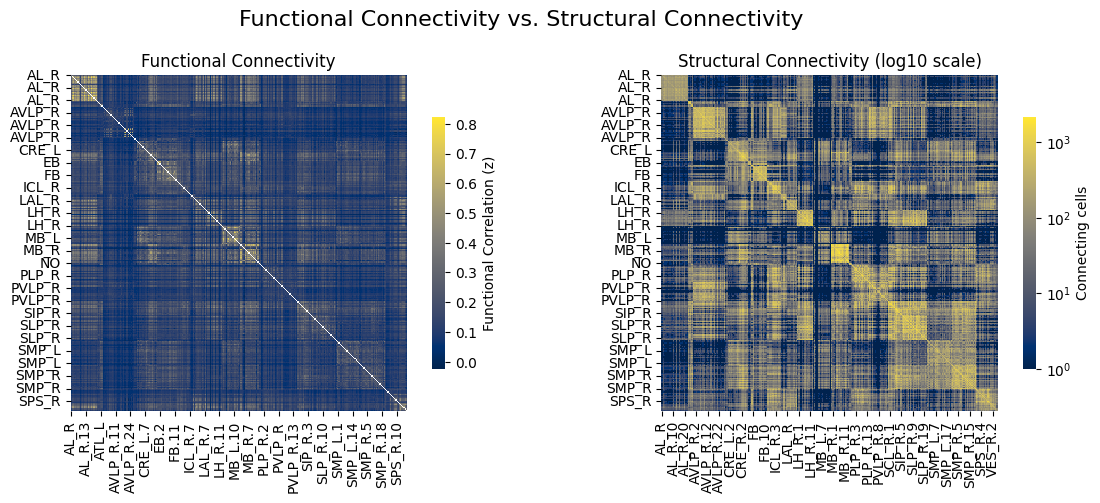

/Users/quanwen/Documents/GitHub/SC-FC/venv/lib/python3.11/site-packages/pandas/core/internals/blocks.py:347: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


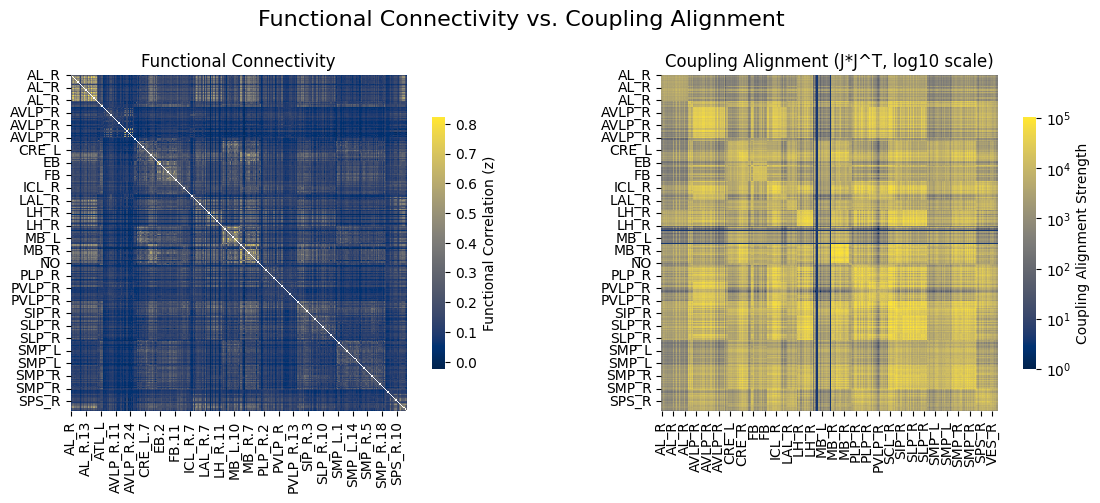

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import os

# This script assumes you have the scfc package installed and the data in the correct location.
# If you are running this from the root of the repository, the paths should be correct.
from scfc import bridge

# --- 1. Load the data ---
data_dir = '/Users/quanwen/Documents/fly-center-brain/data'

# Load Functional Connectivity Matrix
functional_matrix_path = os.path.join(data_dir, 'CorrelationMatrix_branson.csv')
Functional_Matrix = pd.read_csv(functional_matrix_path, index_col=0)

# Load Structural Connectivity Matrix (J)
structural_matrix_path = os.path.join(data_dir, 'StructuralMatrix_branson.csv')
Structural_Matrix = pd.read_csv(structural_matrix_path, index_col=0)

# --- 2. Plot Functional vs Structural ---
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Functional Connectivity vs. Structural Connectivity', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax1[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax1[0].set_title('Functional Connectivity')
ax1[0].set_aspect('equal')

# Structural heatmap
J_for_plotting = Structural_Matrix
np.fill_diagonal(J_for_plotting.values, np.nan) # Replace diagonal with NaN for plotting
sns.heatmap(np.log10(J_for_plotting).replace([np.inf, -np.inf], 0), ax=ax1[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb1 = fig1.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(J_for_plotting.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax1[1], shrink=0.75, label='Connecting cells')
cb1.outline.set_linewidth(0)
ax1[1].set_title('Structural Connectivity (log10 scale)')
ax1[1].set_aspect('equal')

fig1.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 3. Calculate Coupling Alignment Matrix (J * J^T) ---
J = Structural_Matrix
N = J.shape[0]
# Fill diagonal with 0 before matrix multiplication
np.fill_diagonal(J.values, 0)
Coupling_Alignment = (J @ J.T)/N

# --- 4. Plot Functional vs Coupling Alignment ---
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Functional Connectivity vs. Coupling Alignment', fontsize=16)

# Functional heatmap
sns.heatmap(Functional_Matrix, ax=ax2[0],
            #yticklabels=False,
            #xticklabels=False,
            cbar_kws={'label': 'Functional Correlation (z)', 'shrink': .75}, cmap="cividis", rasterized=True)
ax2[0].set_title('Functional Connectivity')
ax2[0].set_aspect('equal')

# Coupling Alignment heatmap
sns.heatmap(np.log10(Coupling_Alignment).replace([np.inf, -np.inf], 0), ax=ax2[1],
            #yticklabels=False,
            #xticklabels=False,
            cmap="cividis", rasterized=True, cbar=False)
cb2 = fig2.colorbar(matplotlib.cm.ScalarMappable(norm=matplotlib.colors.SymLogNorm(vmin=1, vmax=np.nanmax(Coupling_Alignment.to_numpy()), base=10, linthresh=0.1, linscale=1), cmap="cividis"), ax=ax2[1], shrink=0.75, label='Coupling Alignment Strength')
cb2.outline.set_linewidth(0)
ax2[1].set_title('Coupling Alignment (J*J^T, log10 scale)')
ax2[1].set_aspect('equal')

fig2.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
